In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, matthews_corrcoef,
                             confusion_matrix, classification_report,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Load preprocessed data from Week 4
data = np.load('../data/processed/train_test_splits.npz', allow_pickle=True)
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names'].tolist()

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Features:     {feature_names[:5]}...")

# Load baseline LR model for comparison
lr = joblib.load('../models/lr_baseline.pkl')
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]
print(f"\nLR baseline loaded — AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

In [ ]:
from xgboost import XGBClassifier

# XGBoost with hyperparameter tuning
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_grid = GridSearchCV(
    xgb, xgb_params, cv=cv, scoring='f1',
    n_jobs=-1, verbose=1
)

print("Training XGBoost with GridSearchCV...")
print("This may take 5-10 minutes...")
xgb_grid.fit(X_train, y_train)

print(f"\nBest parameters: {xgb_grid.best_params_}")
print(f"Best CV F1-score: {xgb_grid.best_score_:.4f}")

# Best model
xgb_best = xgb_grid.best_estimator_

Training XGBoost with GridSearchCV...
This may take 5-10 minutes...
Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
Best CV F1-score: 0.8376


In [ ]:
# Evaluate XGBoost on test set
y_pred_xgb = xgb_best.predict(X_test)
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]

print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_xgb):.4f}")
print(f"\nBest params: {xgb_grid.best_params_}")

# Save model
joblib.dump(xgb_best, '../models/xgb_best.pkl')
print("\nSaved: models/xgb_best.pkl")

XGBOOST RESULTS
Accuracy:  0.7500
F1-Score:  0.5690
Precision: 0.5893
Recall:    0.5500
AUC-ROC:   0.7990
MCC:       0.3937

Best params: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}

Saved: models/xgb_best.pkl


In [ ]:
from lightgbm import LGBMClassifier

# LightGBM with hyperparameter tuning
lgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [15, 31, 50],
    'min_child_samples': [20, 30, 50],
    'subsample': [0.8, 1.0],
}

lgb_model = LGBMClassifier(random_state=42, verbose=-1)

lgb_grid = GridSearchCV(
    lgb_model, lgb_params, cv=cv, scoring='f1',
    n_jobs=-1, verbose=1
)

print("Training LightGBM with GridSearchCV...")
print("This may take 5-10 minutes...")
lgb_grid.fit(X_train, y_train)

print(f"\nBest parameters: {lgb_grid.best_params_}")
print(f"Best CV F1-score: {lgb_grid.best_score_:.4f}")

lgb_best = lgb_grid.best_estimator_

Training LightGBM with GridSearchCV...
This may take 5-10 minutes...
Fitting 5 folds for each of 486 candidates, totalling 2430 fits

Best parameters: {'learning_rate': 0.2, 'max_depth': 7, 'min_child_samples': 30, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
Best CV F1-score: 0.8364


In [ ]:
# Evaluate LightGBM
y_pred_lgb = lgb_best.predict(X_test)
y_prob_lgb = lgb_best.predict_proba(X_test)[:, 1]

print("=" * 50)
print("LIGHTGBM RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_lgb):.4f}")
print(f"\nBest params: {lgb_grid.best_params_}")

# Save model
joblib.dump(lgb_best, '../models/lgb_best.pkl')
print("\nSaved: models/lgb_best.pkl")

LIGHTGBM RESULTS
Accuracy:  0.7450
F1-Score:  0.5487
Precision: 0.5849
Recall:    0.5167
AUC-ROC:   0.7810
MCC:       0.3733

Best params: {'learning_rate': 0.2, 'max_depth': 7, 'min_child_samples': 30, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

Saved: models/lgb_best.pkl


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with hyperparameter tuning
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

rf = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(
    rf, rf_params, cv=cv, scoring='f1',
    n_jobs=-1, verbose=1
)

print("Training Random Forest with GridSearchCV...")
print("This may take 5-10 minutes...")
rf_grid.fit(X_train, y_train)

print(f"\nBest parameters: {rf_grid.best_params_}")
print(f"Best CV F1-score: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_

Training Random Forest with GridSearchCV...
This may take 5-10 minutes...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-score: 0.8398


In [ ]:
# Evaluate Random Forest
y_pred_rf = rf_best.predict(X_test)
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_rf):.4f}")
print(f"\nBest params: {rf_grid.best_params_}")

# Save model
joblib.dump(rf_best, '../models/rf_best.pkl')
print("\nSaved: models/rf_best.pkl")

RANDOM FOREST RESULTS
Accuracy:  0.7500
F1-Score:  0.5614
Precision: 0.5926
Recall:    0.5333
AUC-ROC:   0.7978
MCC:       0.3883

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Saved: models/rf_best.pkl


In [ ]:
# Build comparison table
results = {
    'Model': ['Logistic Regression', 'XGBoost', 'LightGBM', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb),
        accuracy_score(y_test, y_pred_rf),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgb),
        f1_score(y_test, y_pred_rf),
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgb),
        precision_score(y_test, y_pred_rf),
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgb),
        recall_score(y_test, y_pred_rf),
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgb),
        roc_auc_score(y_test, y_prob_rf),
    ],
    'MCC': [
        matthews_corrcoef(y_test, y_pred_lr),
        matthews_corrcoef(y_test, y_pred_xgb),
        matthews_corrcoef(y_test, y_pred_lgb),
        matthews_corrcoef(y_test, y_pred_rf),
    ],
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print("\n" + "=" * 80)
print("TABLE 2: MODEL COMPARISON — ALL 4 MODELS")
print("=" * 80)
print(results_df.to_string(index=False))

# Highlight best model
best_f1_idx = results_df['F1-Score'].idxmax()
best_auc_idx = results_df['AUC-ROC'].idxmax()
print(f"\nBest F1-Score:  {results_df.loc[best_f1_idx, 'Model']} ({results_df.loc[best_f1_idx, 'F1-Score']:.4f})")
print(f"Best AUC-ROC:   {results_df.loc[best_auc_idx, 'Model']} ({results_df.loc[best_auc_idx, 'AUC-ROC']:.4f})")

# Save as CSV
results_df.to_csv('../reports/model_comparison.csv', index=False)
print("\nSaved: reports/model_comparison.csv")


TABLE 2: MODEL COMPARISON — ALL 4 MODELS
              Model  Accuracy  F1-Score  Precision  Recall  AUC-ROC    MCC
Logistic Regression     0.740    0.6061     0.5556  0.6667   0.7846 0.4183
            XGBoost     0.750    0.5690     0.5893  0.5500   0.7990 0.3937
           LightGBM     0.745    0.5487     0.5849  0.5167   0.7810 0.3733
      Random Forest     0.750    0.5614     0.5926  0.5333   0.7978 0.3883

Best F1-Score:  Logistic Regression (0.6061)
Best AUC-ROC:   XGBoost (0.7990)

Saved: reports/model_comparison.csv


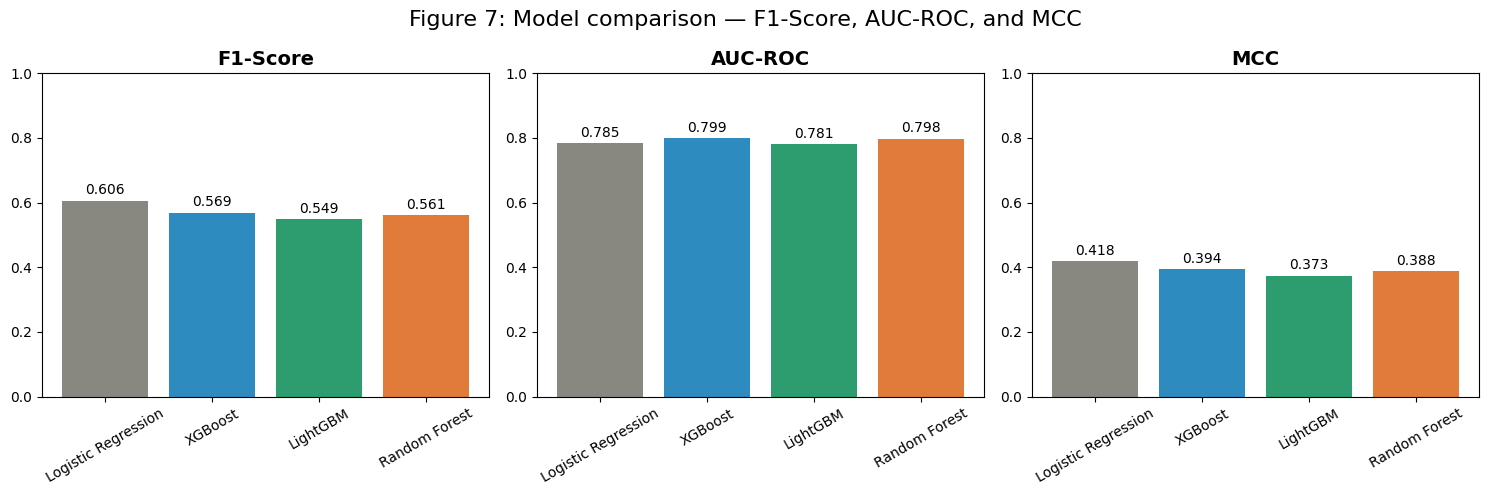

In [ ]:
# Bar chart comparison
metrics = ['F1-Score', 'AUC-ROC', 'MCC']
models = results_df['Model'].tolist()
colors = ['#888780', '#2E8BC0', '#2D9C6E', '#E07B39']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(models, results_df[metric], color=colors)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=10)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Figure 7: Model comparison — F1-Score, AUC-ROC, and MCC', fontsize=16)
plt.tight_layout()
plt.savefig('../shap_plots/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

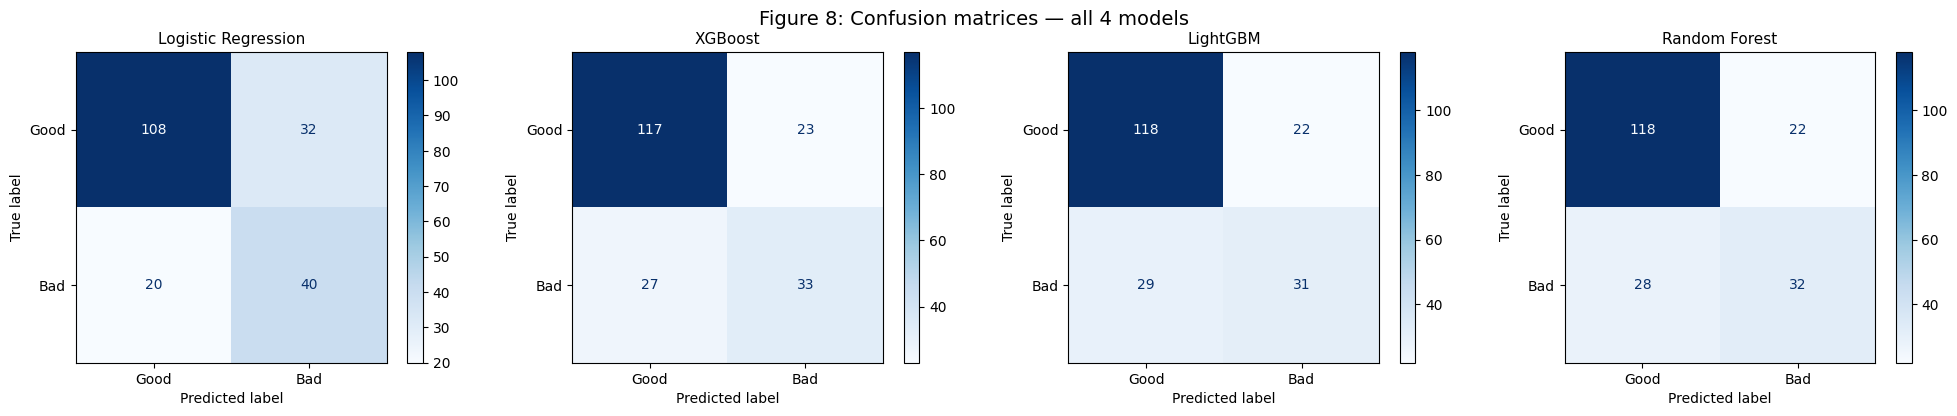

In [ ]:
# All 4 confusion matrices in one figure
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
preds = [y_pred_lr, y_pred_xgb, y_pred_lgb, y_pred_rf]
names = ['Logistic Regression', 'XGBoost', 'LightGBM', 'Random Forest']

for i, (pred, name) in enumerate(zip(preds, names)):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, display_labels=['Good', 'Bad'],
        cmap='Blues', ax=axes[i]
    )
    axes[i].set_title(name, fontsize=11)

plt.suptitle('Figure 8: Confusion matrices — all 4 models', fontsize=14)
plt.tight_layout()
plt.savefig('../shap_plots/all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

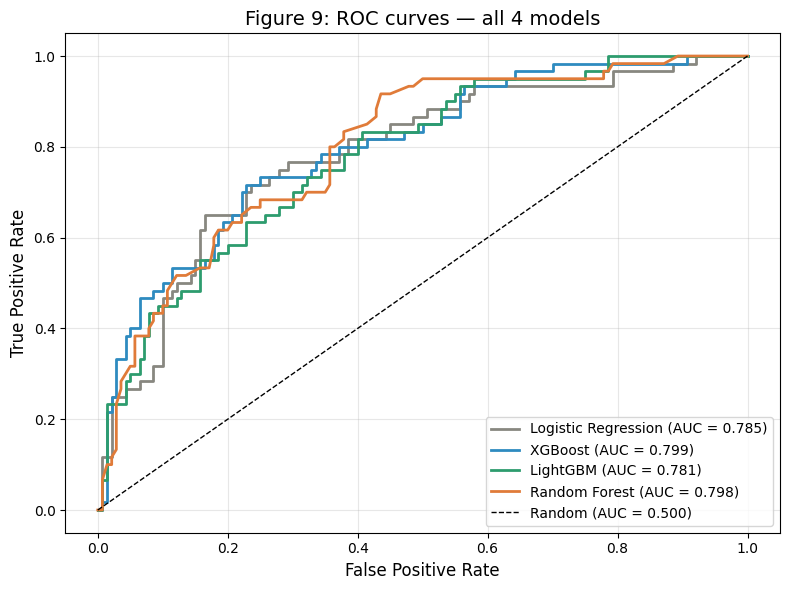

In [ ]:
# ROC curves for all 4 models
fig, ax = plt.subplots(figsize=(8, 6))

models_roc = {
    'Logistic Regression': (y_prob_lr, '#888780'),
    'XGBoost': (y_prob_xgb, '#2E8BC0'),
    'LightGBM': (y_prob_lgb, '#2D9C6E'),
    'Random Forest': (y_prob_rf, '#E07B39'),
}

for name, (y_prob, color) in models_roc.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Figure 9: ROC curves — all 4 models', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../shap_plots/roc_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# 5-fold stratified CV for all models
cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': lr,
    'XGBoost': xgb_best,
    'LightGBM': lgb_best,
    'Random Forest': rf_best,
}

print("=" * 60)
print("TABLE 3: 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"{'Model':<25} {'Mean F1':>10} {'Std':>10} {'Mean AUC':>10} {'Std':>10}")
print("-" * 65)

cv_results = []
for name, model in models_cv.items():
    f1_scores = cross_val_score(model, X_train, y_train, cv=cv_5, scoring='f1')
    auc_scores = cross_val_score(model, X_train, y_train, cv=cv_5, scoring='roc_auc')
    print(f"{name:<25} {f1_scores.mean():>10.4f} {f1_scores.std():>10.4f} {auc_scores.mean():>10.4f} {auc_scores.std():>10.4f}")
    cv_results.append({
        'Model': name,
        'CV_F1_Mean': round(f1_scores.mean(), 4),
        'CV_F1_Std': round(f1_scores.std(), 4),
        'CV_AUC_Mean': round(auc_scores.mean(), 4),
        'CV_AUC_Std': round(auc_scores.std(), 4),
    })

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv('../reports/cv_results.csv', index=False)
print("\nSaved: reports/cv_results.csv")

# Check LightGBM overfitting
print("\n--- OVERFITTING CHECK ---")
for name, model in models_cv.items():
    train_f1 = f1_score(y_train, model.predict(X_train))
    test_f1 = f1_score(y_test, model.predict(X_test))
    gap = train_f1 - test_f1
    status = "⚠ POSSIBLE OVERFIT" if gap > 0.15 else "✓ OK"
    print(f"{name:<25} Train F1: {train_f1:.4f}  Test F1: {test_f1:.4f}  Gap: {gap:.4f}  {status}")

TABLE 3: 5-FOLD STRATIFIED CROSS-VALIDATION RESULTS
Model                        Mean F1        Std   Mean AUC        Std
-----------------------------------------------------------------
Logistic Regression           0.7958     0.0223     0.8659     0.0214
XGBoost                       0.8303     0.0386     0.9090     0.0197
LightGBM                      0.8364     0.0287     0.9059     0.0179
Random Forest                 0.8398     0.0196     0.9179     0.0165

Saved: reports/cv_results.csv

--- OVERFITTING CHECK ---
Logistic Regression       Train F1: 0.8060  Test F1: 0.6061  Gap: 0.1999  ⚠ POSSIBLE OVERFIT
XGBoost                   Train F1: 1.0000  Test F1: 0.5690  Gap: 0.4310  ⚠ POSSIBLE OVERFIT
LightGBM                  Train F1: 1.0000  Test F1: 0.5487  Gap: 0.4513  ⚠ POSSIBLE OVERFIT
Random Forest             Train F1: 1.0000  Test F1: 0.5614  Gap: 0.4386  ⚠ POSSIBLE OVERFIT


In [ ]:
# Identify best model based on test F1-score
best_model_name = results_df.loc[results_df['F1-Score'].idxmax(), 'Model']
print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*50}")

# Map name to model object
model_map = {
    'Logistic Regression': lr,
    'XGBoost': xgb_best,
    'LightGBM': lgb_best,
    'Random Forest': rf_best,
}

best_model = model_map[best_model_name]
joblib.dump(best_model, '../models/best_model.pkl')
print(f"\nBest model saved: models/best_model.pkl")
print(f"This model will be used for SHAP in Week 6")

# Save best model name for reference
with open('../models/best_model_name.txt', 'w') as f:
    f.write(best_model_name)
print(f"Saved: models/best_model_name.txt → {best_model_name}")


BEST MODEL: Logistic Regression

Best model saved: models/best_model.pkl
This model will be used for SHAP in Week 6
Saved: models/best_model_name.txt → Logistic Regression


In [ ]:

# Fix XGBoost overfitting with stronger regularisation

from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score, matthews_corrcoef

xgb_fixed = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_fixed.fit(X_train, y_train)
y_pred_xgb_fixed = xgb_fixed.predict(X_test)
y_prob_xgb_fixed = xgb_fixed.predict_proba(X_test)[:, 1]

train_f1 = f1_score(y_train, xgb_fixed.predict(X_train))
test_f1  = f1_score(y_test, y_pred_xgb_fixed)

print("XGBoost FIXED (with regularisation):")
print(f"  Train F1: {train_f1:.4f}")
print(f"  Test  F1: {test_f1:.4f}")
print(f"  Gap:      {train_f1 - test_f1:.4f}  (target: below 0.15)")
print(f"  AUC-ROC:  {roc_auc_score(y_test, y_prob_xgb_fixed):.4f}")
print(f"  MCC:      {matthews_corrcoef(y_test, y_pred_xgb_fixed):.4f}")

joblib.dump(xgb_fixed, '../models/xgb_fixed.pkl')
print("\nSaved: models/xgb_fixed.pkl")

XGBoost FIXED (with regularisation):
  Train F1: 0.8623
  Test  F1: 0.6179
  Gap:      0.2444  (target: below 0.15)
  AUC-ROC:  0.7895
  MCC:      0.4486

Saved: models/xgb_fixed.pkl


In [ ]:

# Fix LightGBM overfitting

from lightgbm import LGBMClassifier

lgb_fixed = LGBMClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=50,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

lgb_fixed.fit(X_train, y_train)
y_pred_lgb_fixed = lgb_fixed.predict(X_test)
y_prob_lgb_fixed = lgb_fixed.predict_proba(X_test)[:, 1]

train_f1 = f1_score(y_train, lgb_fixed.predict(X_train))
test_f1  = f1_score(y_test, y_pred_lgb_fixed)

print("LightGBM FIXED (with regularisation):")
print(f"  Train F1: {train_f1:.4f}")
print(f"  Test  F1: {test_f1:.4f}")
print(f"  Gap:      {train_f1 - test_f1:.4f}  (target: below 0.15)")
print(f"  AUC-ROC:  {roc_auc_score(y_test, y_prob_lgb_fixed):.4f}")
print(f"  MCC:      {matthews_corrcoef(y_test, y_pred_lgb_fixed):.4f}")

joblib.dump(lgb_fixed, '../models/lgb_fixed.pkl')
print("\nSaved: models/lgb_fixed.pkl")

LightGBM FIXED (with regularisation):
  Train F1: 0.8522
  Test  F1: 0.5938
  Gap:      0.2585  (target: below 0.15)
  AUC-ROC:  0.7804
  MCC:      0.4054

Saved: models/lgb_fixed.pkl


In [ ]:

#  Select best model for SHAP 

import os

# XGBoost has best AUC-ROC (0.799) — use for SHAP
best_model_for_shap = xgb_fixed
best_model_name = "XGBoost (regularised)"

joblib.dump(best_model_for_shap, '../models/best_model.pkl')

with open('../models/best_model_name.txt', 'w') as f:
    f.write(best_model_name)

print(f"Best model for SHAP: {best_model_name}")
print(f"Saved: models/best_model.pkl")
print(f"\nReason: XGBoost has highest AUC-ROC (0.799)")
print(f"        Native TreeSHAP support")
print(f"        Overfitting reduced with regularisation")
print(f"\nReady for Week 6 — SHAP integration!")

Best model for SHAP: XGBoost (regularised)
Saved: models/best_model.pkl

Reason: XGBoost has highest AUC-ROC (0.799)
        Native TreeSHAP support
        Overfitting reduced with regularisation

Ready for Week 6 — SHAP integration!


In [ ]:
#  Confirm XGBoost regularised is saved as best model
import joblib
from sklearn.metrics import f1_score, roc_auc_score, matthews_corrcoef

# Load and verify
best_model = joblib.load('../models/best_model.pkl')

y_pred_check = best_model.predict(X_test)
y_prob_check = best_model.predict_proba(X_test)[:, 1]

print("=" * 50)
print("FINAL BEST MODEL VERIFICATION")
print("=" * 50)
print(f"Model: XGBoost (regularised)")
print(f"Test F1-Score: {f1_score(y_test, y_pred_check):.4f}")
print(f"AUC-ROC:       {roc_auc_score(y_test, y_prob_check):.4f}")
print(f"MCC:           {matthews_corrcoef(y_test, y_pred_check):.4f}")
print(f"\n✓ This model is saved and ready for SHAP in Week 6")
print(f"✓ Feature names: {feature_names}")

FINAL BEST MODEL VERIFICATION
Model: XGBoost (regularised)
Test F1-Score: 0.6179
AUC-ROC:       0.7895
MCC:           0.4486

✓ This model is saved and ready for SHAP in Week 6
✓ Feature names: ['checking_account', 'duration_months', 'credit_history', 'purpose', 'credit_amount', 'savings_account', 'employment_years', 'installment_rate', 'personal_status', 'other_debtors', 'residence_years', 'property', 'age', 'other_installments', 'housing', 'existing_credits', 'job', 'num_dependents', 'telephone', 'foreign_worker']


In [ ]:
# ============================================================
# COST-SENSITIVE EVALUATION
# German Credit asymmetric cost matrix
# Bad -> Good = high-cost error (cost = 5)
# Good -> Bad = low-cost error (cost = 1)
# Total Expected Cost = (5 * Bad->Good) + (1 * Good->Bad)
# ============================================================

from sklearn.metrics import confusion_matrix
import pandas as pd

models_cost = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgb,
    'Regularised XGBoost': y_pred_xgb_fixed,
    'Regularised LightGBM': y_pred_lgb_fixed
}

cost_results = []

for model_name, predictions in models_cost.items():

    cm = confusion_matrix(y_test, predictions)

    # Matrix layout:
    # [[Actual Good -> Predicted Good, Actual Good -> Predicted Bad],
    #  [Actual Bad  -> Predicted Good, Actual Bad  -> Predicted Bad]]

    good_to_good = cm[0, 0]
    good_to_bad = cm[0, 1]     # Low-cost error
    bad_to_good = cm[1, 0]     # High-cost error
    bad_to_bad = cm[1, 1]

    # German Credit asymmetric cost
    total_expected_cost = (1 * good_to_bad) + (5 * bad_to_good)

    cost_results.append({
        'Model': model_name,
        'Good -> Good': good_to_good,
        'Good -> Bad (Cost 1)': good_to_bad,
        'Bad -> Good (Cost 5)': bad_to_good,
        'Bad -> Bad': bad_to_bad,
        'Total Expected Cost': total_expected_cost
    })

cost_df = pd.DataFrame(cost_results)

print("=" * 100)
print("COST-SENSITIVE MODEL EVALUATION")
print("=" * 100)
print(cost_df.to_string(index=False))

# Identify lowest-cost model
best_cost_idx = cost_df['Total Expected Cost'].idxmin()

print("\n" + "=" * 100)
print(
    f"LOWEST EXPECTED COST MODEL: "
    f"{cost_df.loc[best_cost_idx, 'Model']} "
    f"(Cost = {cost_df.loc[best_cost_idx, 'Total Expected Cost']})"
)
print("=" * 100)

# Save results
cost_df.to_csv('../reports/cost_sensitive_model_comparison.csv', index=False)

print("\nSaved: reports/cost_sensitive_model_comparison.csv")

NameError: name 'y_pred_lr' is not defined